In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

In [85]:
inputs = xr.open_dataset("../model_input_dataset.nc")
outputs = xr.open_dataset("../model_output_dataset.nc")

index2name = {10: "Ross",
              11: "Filchner-Ronne",
              31: "Amery",
              52: "Dotson",
              66: "Pine Island",
              43: "Riiser-Larsen",
              48: "Totten",
              45: "Baudouin",
              33: "Moscow Univ."
             }

def correlation(X,Y):
    std_X = np.nanstd(X)
    std_Y = np.nanstd(Y)
    E_X = np.nanmean(X)
    E_Y = np.nanmean(Y)
    E_XY = np.nanmean(X*Y)
    return (E_XY-E_X*E_Y)/(std_X*std_Y)

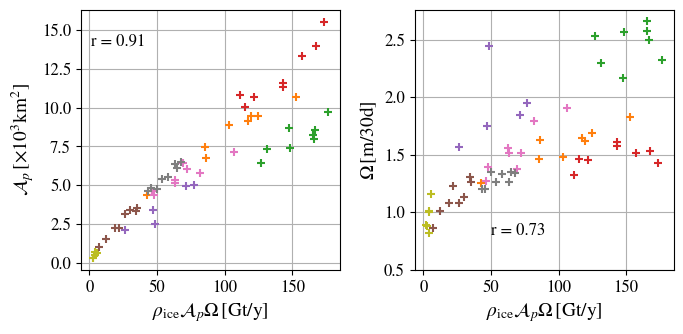

In [154]:
Ap_list = inputs.Ap.groupby(inputs.time.dt.year).mean().values #m^2 Polynya area


Omega_list = inputs.Omega.groupby(inputs.time.dt.year).mean().values /30/24/3600 #m/s Freezing rate

cond = Omega_list*30*24*3600<0.5 # To not take into account values under the threshold Omega < 0.5 m/30d 
cond = ~(~(Omega_list*30*24*3600<0.5) * ~(Ap_list>2e10)) # If you want to naot take into accont too big polynyas too
Ap_list = np.ma.masked_where(cond,Ap_list)
Omega_list = np.ma.masked_where(cond,Omega_list)

SIF_list = 910*Ap_list*Omega_list # kg/s Sea-Ice Formation rate


#Plot
name = inputs.name_isf.values

fig, ax = plt.subplots(1,2,figsize=(7,3.5))

for k in range(9):
    ax[0].scatter(SIF_list[k]*24*3600*365.25/1e12,
                  Ap_list[k]/1e9,
                  zorder=2,marker='+', label=name[k])
    ax[1].scatter(SIF_list[k]*24*3600*365.25/1e12,
                  Omega_list[k]*30*34*3600,
                  zorder=2,marker='+')

ax[0].set_ylabel(r'$\mathcal{A}_p \,\mathrm{[\times 10^3 km^2]}$')
ax[1].set_ylabel(r'$\Omega \, \mathrm{[m/30d]}$')

ax[1].set_ylim(ymin=0.5) #threshold on Omega to detect polynyas

#ax[0].legend()

r_Ap_SIF = correlation(Ap_list,SIF_list)
r_Omega_SIF = correlation(Omega_list,SIF_list)

ax[0].text(1,14,'r = '+str(np.round(r_Ap_SIF,2)))
ax[1].text(50,0.8,'r = '+str(np.round(r_Omega_SIF,2)))

for i in range(2):
    ax[i].grid()
    ax[i].set_xlabel(r'$\rho_\mathrm{ice}\mathcal{A}_p\Omega \, \mathrm{[Gt/y]}$')


plt.tight_layout()
plt.show()